In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

In [2]:
FOOD_CAT = 101 + 80
IMG_SIZE = (224, 224)
IMG_SHAPE = (IMG_SIZE) + (3,)
BATCH_SIZE = 32
DATASET_SIZE = 72400

In [3]:
train_dir = image_dataset_from_directory(
    "/kaggle/input/dataset/Train/Train",
    shuffle = True,
    image_size= IMG_SIZE,
    batch_size= BATCH_SIZE,
    label_mode= "categorical"
)

Found 57838 files belonging to 181 classes.


In [4]:
test_dir = image_dataset_from_directory(
    "/kaggle/input/dataset/Test/Test",
    shuffle = True,
    image_size= IMG_SIZE,
    batch_size= BATCH_SIZE,
    label_mode= "categorical"
)

Found 14493 files belonging to 181 classes.


In [5]:
tf.data.experimental.cardinality(train_dir).numpy()

1808

In [6]:
tf.data.experimental.cardinality(test_dir).numpy()

453

In [7]:
class_names = train_dir.class_names

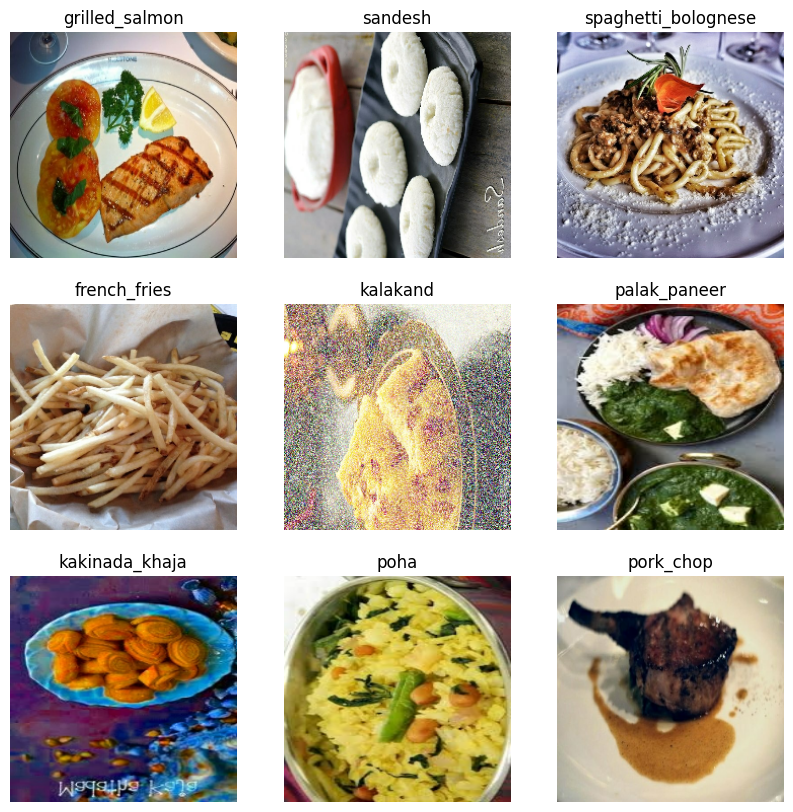

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_dir.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")

In [51]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [52]:
AUTOTUNE = tf.data.AUTOTUNE

train_dir = train_dir.prefetch(buffer_size=AUTOTUNE)
test_dir = test_dir.prefetch(buffer_size=AUTOTUNE)

In [53]:
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)

In [54]:
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [55]:
base_model.trainable = False

In [56]:
for image_batch, label_batch in train_dir.take(1):
    feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 7, 7, 1280)


In [57]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [58]:
prediction_layer = Dense(FOOD_CAT, activation='softmax')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 181)


In [59]:
x = base_model.input
x = preprocess_input(x)
x = base_model(x, training= False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.4)(x)
predictions = prediction_layer(x)

In [60]:
model = Model(inputs=base_model.input, outputs= predictions)

In [61]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 181)                 │         231,861 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,489,845 (9.50 MB)

 Trainable params: 231,861 (905.71 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

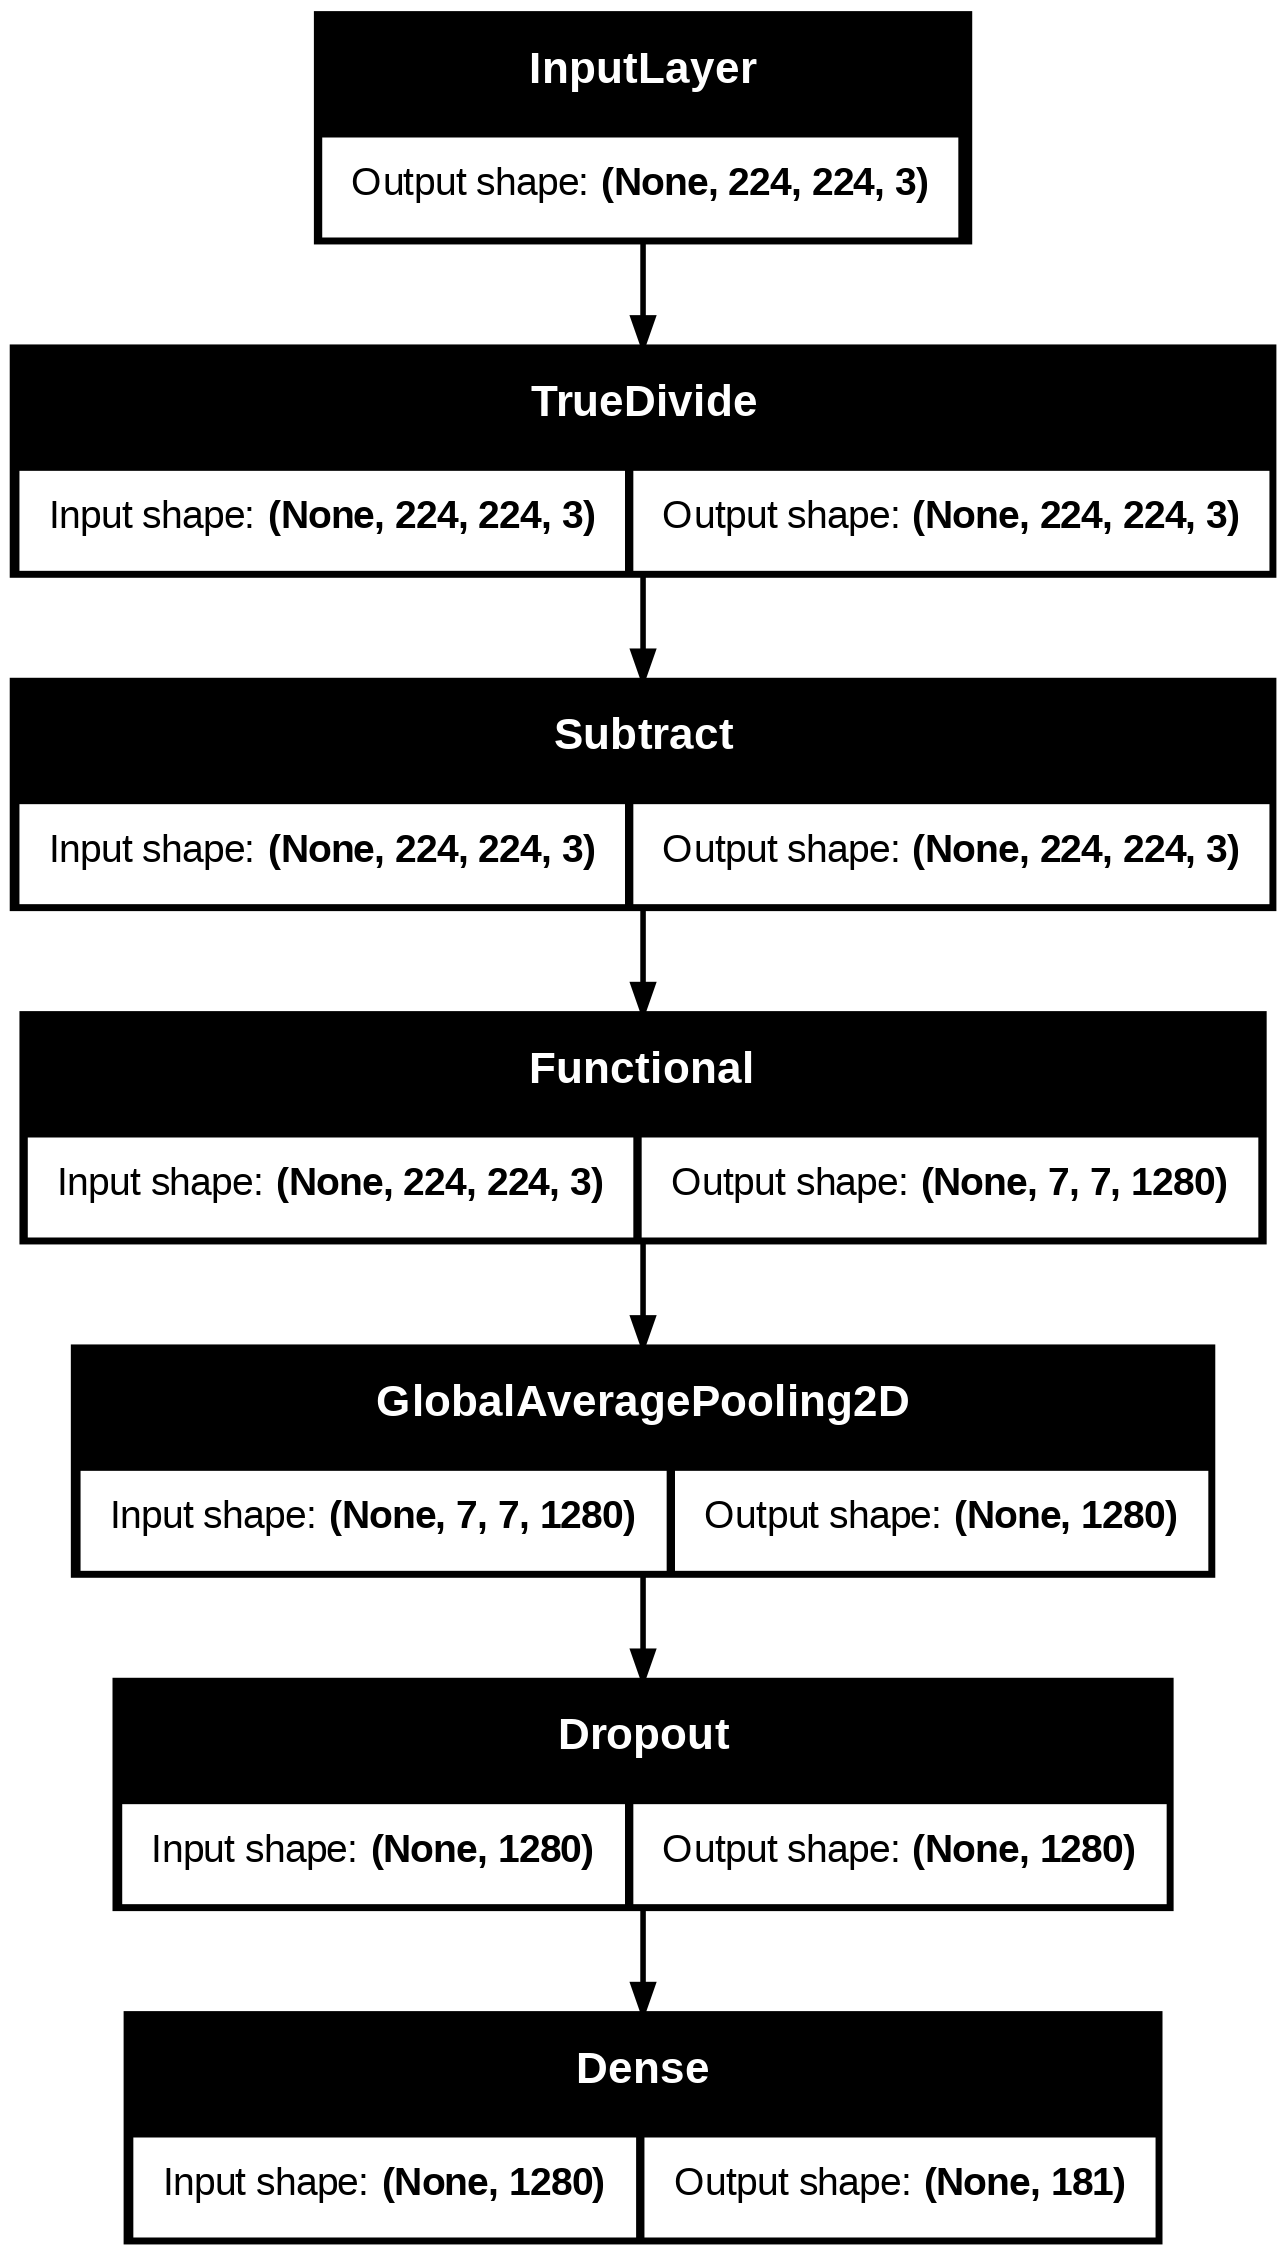

In [62]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [63]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [64]:
history = model.fit(
    train_dir,
    validation_data= test_dir,
    epochs=10,
)

Epoch 1/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 119s 62ms/step - accuracy: 0.2500 - loss: 3.5051 - val_accuracy: 0.5066 - val_loss: 1.9967
Epoch 2/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 98s 54ms/step - accuracy: 0.4942 - loss: 2.0319 - val_accuracy: 0.5397 - val_loss: 1.8629
Epoch 3/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 98s 54ms/step - accuracy: 0.5320 - loss: 1.8586 - val_accuracy: 0.5508 - val_loss: 1.8169
Epoch 4/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 98s 54ms/step - accuracy: 0.5470 - loss: 1.7768 - val_accuracy: 0.5664 - val_loss: 1.7820
Epoch 5/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 98s 54ms/step - accuracy: 0.5592 - loss: 1.7337 - val_accuracy: 0.5638 - val_loss: 1.7916
Epoch 6/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 98s 54ms/step - accuracy: 0.5694 - loss: 1.6926 - val_accuracy: 0.5696 - val_loss: 1.7796
Epoch 7/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 98s 54ms/step - accuracy: 0.5742 - loss: 1.6733 - val_accuracy: 0.5753 - val_loss: 1.7857
Epoch 8/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 99s 54ms/step - accuracy: 0.5793 

In [65]:
loss, accuracy = model.evaluate(test_dir)
print(f"Test Accuracy: {accuracy:.2f}")

453/453 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5826 - loss: 1.7927
Test Accuracy: 0.58


In [66]:
base_model.trainable = True

In [67]:
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  154


In [68]:
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [69]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001, decay_steps=1000, decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


In [70]:
early_stop = EarlyStopping(
    monitor= "val_loss",
    patience= 7,
    restore_best_weights= True,
    start_from_epoch= 10,)

In [71]:
checkpoint = tf.keras.callbacks.ModelCheckpoint("mobilenetv2_best_model.keras", save_best_only=True, monitor="val_accuracy")

In [72]:
model.compile(
    optimizer= optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [73]:
history_finetune = model.fit(
    train_dir,
    validation_data= test_dir,
    epochs= 30,
    callbacks= [early_stop, checkpoint]
    )

Epoch 1/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 135s 64ms/step - accuracy: 0.3466 - loss: 2.7845 - val_accuracy: 0.1944 - val_loss: 5.6144
Epoch 2/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 106s 58ms/step - accuracy: 0.5737 - loss: 1.6071 - val_accuracy: 0.3150 - val_loss: 3.5074
Epoch 3/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 106s 58ms/step - accuracy: 0.6684 - loss: 1.2043 - val_accuracy: 0.4915 - val_loss: 2.0604
Epoch 4/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 105s 58ms/step - accuracy: 0.7465 - loss: 0.8986 - val_accuracy: 0.5494 - val_loss: 1.8928
Epoch 5/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 105s 58ms/step - accuracy: 0.8081 - loss: 0.6553 - val_accuracy: 0.5830 - val_loss: 1.8549
Epoch 6/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 106s 58ms/step - accuracy: 0.8570 - loss: 0.4708 - val_accuracy: 0.6615 - val_loss: 1.4801
Epoch 7/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 106s 58ms/step - accuracy: 0.8973 - loss: 0.3337 - val_accuracy: 0.6796 - val_loss: 1.3671
Epoch 8/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 105s 58ms/step - accuracy: 

In [74]:
test_loss, test_accuracy = model.evaluate(test_dir)
print(f"Test Accuracy: {test_accuracy:.2f}")

453/453 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.7388 - loss: 1.4060
Test Accuracy: 0.74


In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(50, 50))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_dir:  
    predictions = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━

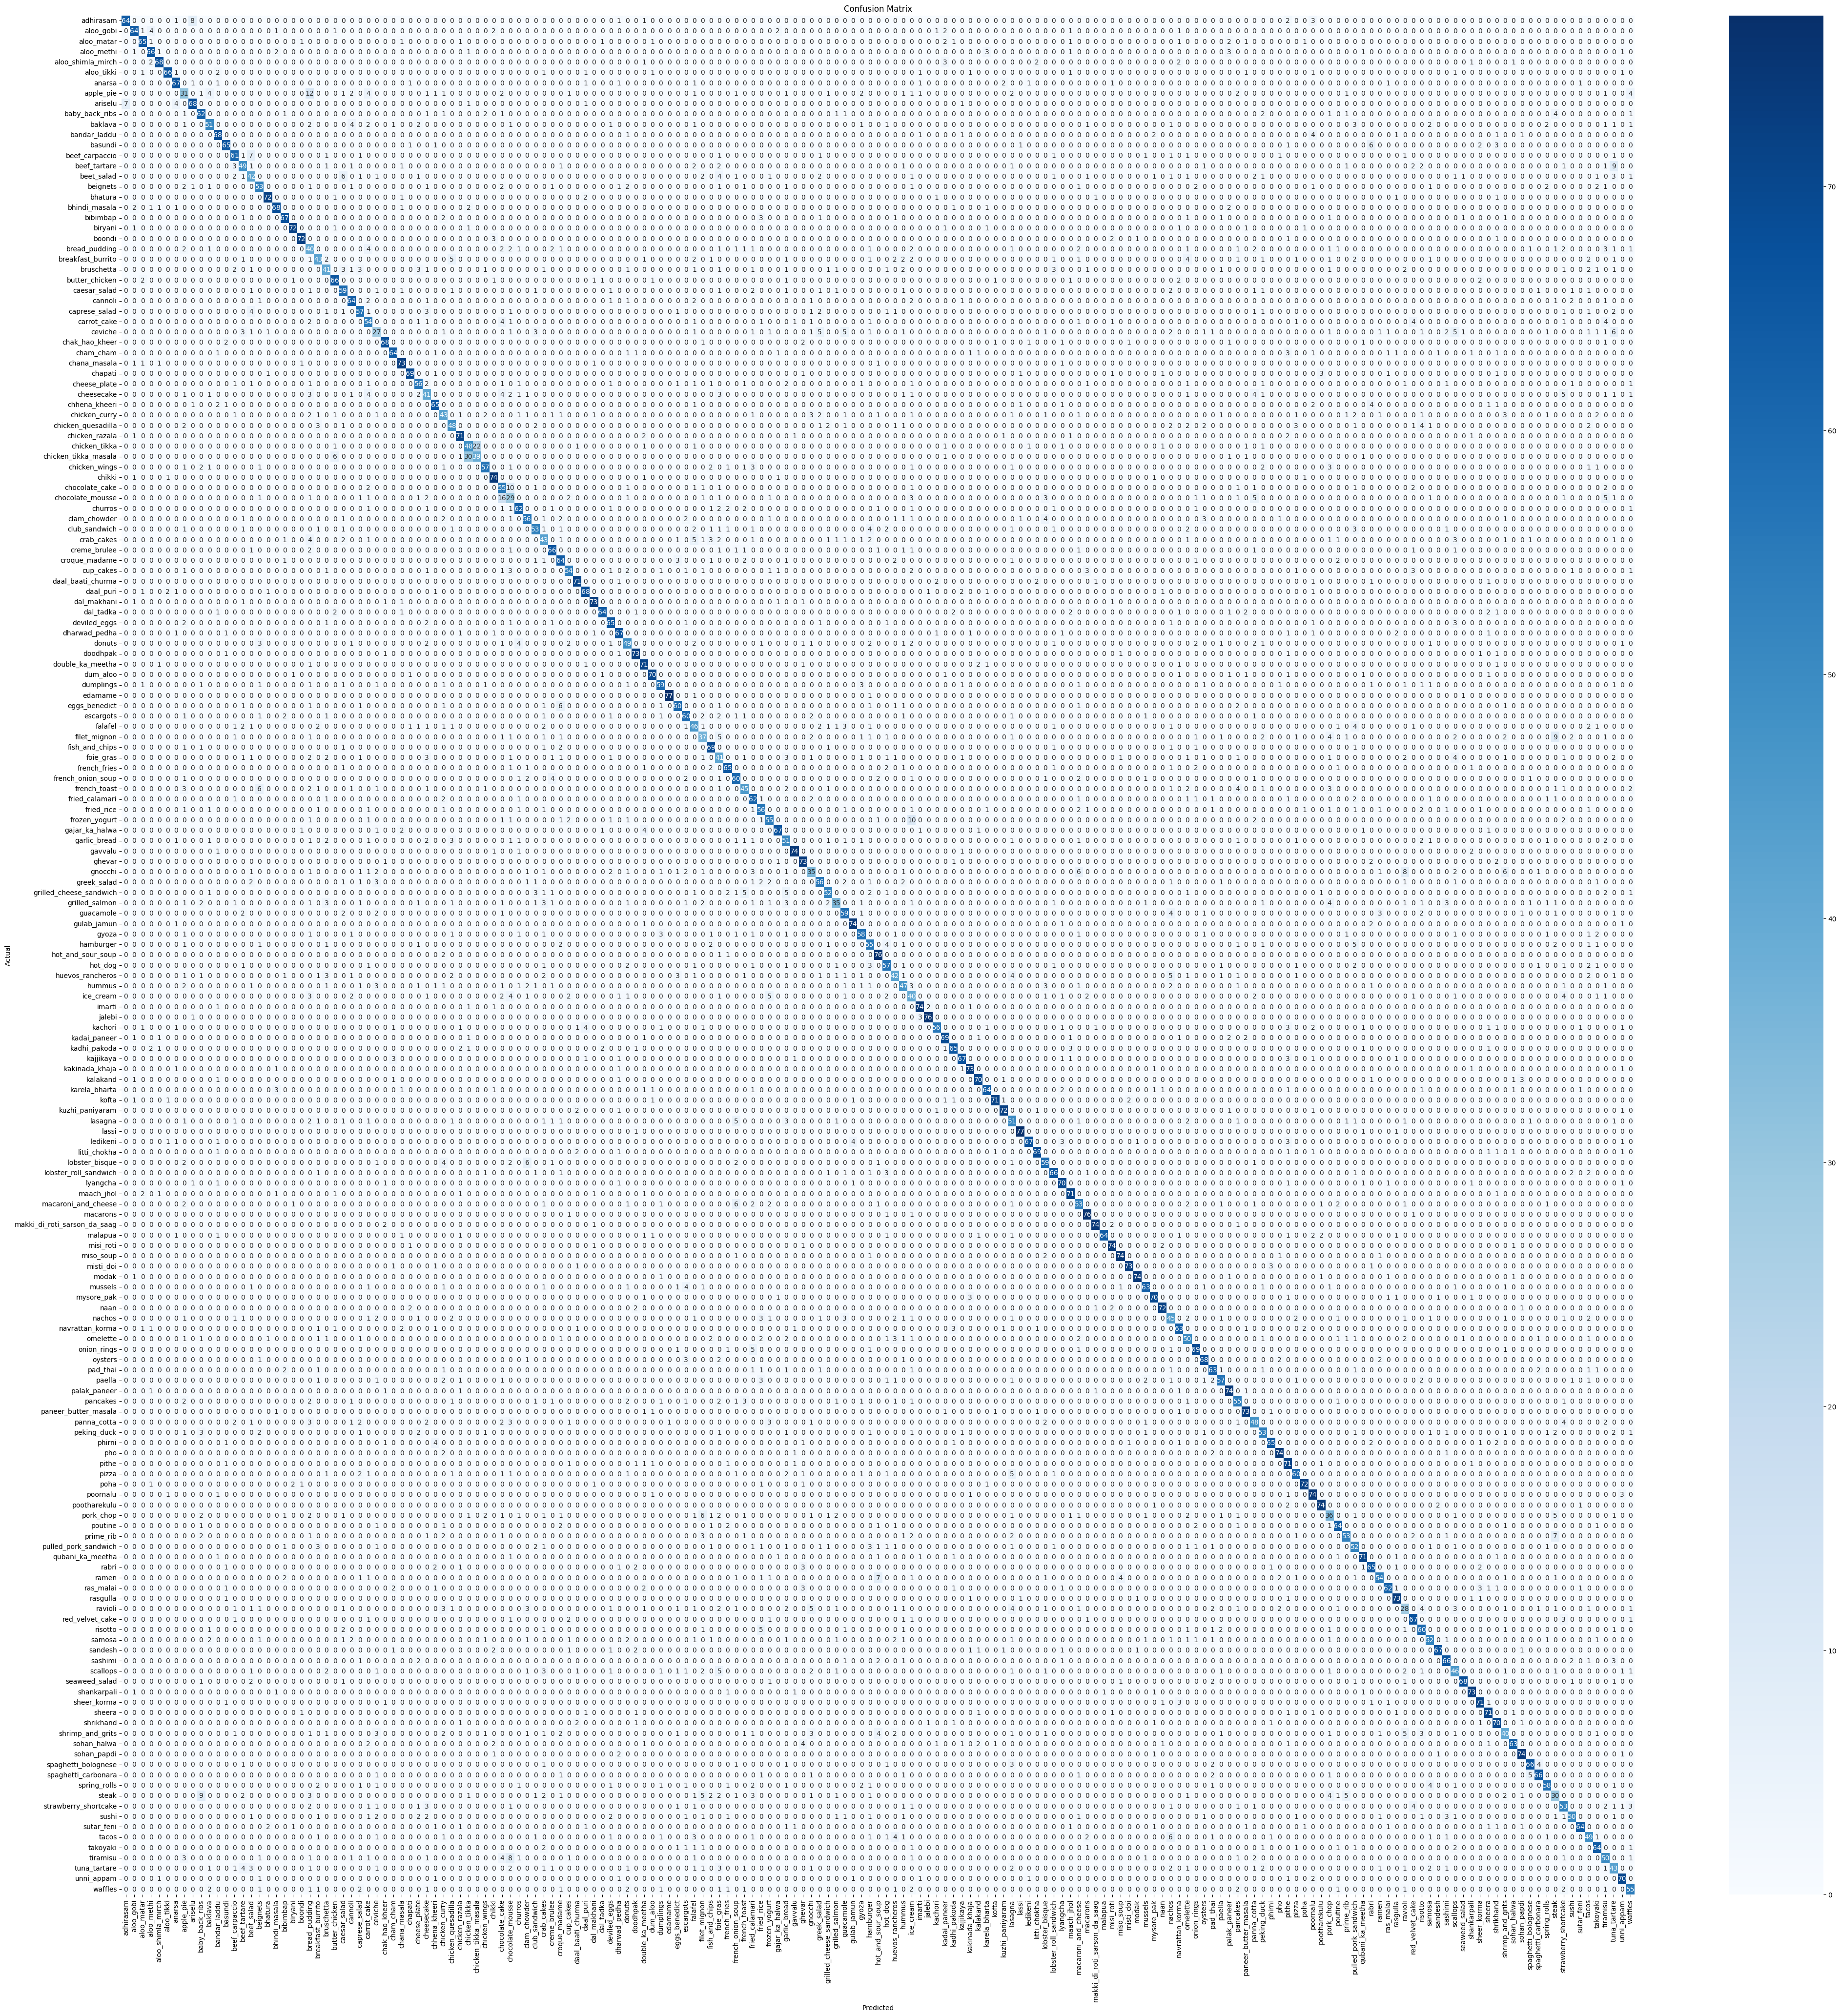

In [ ]:
plot_confusion_matrix(y_true, y_pred, class_names)

In [ ]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                              precision    recall  f1-score   support

                   adhirasam       0.90      0.80      0.85        80
                   aloo_gobi       0.83      0.80      0.82        80
                  aloo_matar       0.86      0.81      0.83        80
                  aloo_methi       0.84      0.82      0.83        80
           aloo_shimla_mirch       0.89      0.85      0.87        80
                  aloo_tikki       0.92      0.82      0.87        80
                      anarsa       0.82      0.84      0.83        80
                   apple_pie       0.44      0.39      0.41        80
                     ariselu       0.84      0.83      0.83        82
              baby_back_ribs       0.70      0.78      0.73        80
                     baklava       0.75      0.64      0.69        80
                bandar_laddu       0.81      0.85      0.83        80
                     basundi       0.86      0.81      0.83       